# Water Chemistry ODE — Protoplanetary Disk UV Variability

A two-level ODE model for time-dependent water abundance in a protoplanetary disk warm layer, driven by a time-varying UV field. Motivated by JWST observations of DQ Tau-like systems.

**ODE:**
$$\frac{dx}{dt} = k_{\rm form}(T, n_H) \cdot (\varepsilon_O - x) - k_{\rm pd}(G(t)) \cdot x$$

where $x = n(\rm H_2O)/n_H$ is the water abundance relative to the total hydrogen number density, and $\varepsilon_O = n_O/n_H$ is the elemental oxygen abundance available for water chemistry.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

%matplotlib inline


## 1. Reaction rates

In [2]:
def k_photodiss(G):
    """
    Water photodissociation rate [s^-1].
    k0 ~ 1e-9 s^-1 in the standard Draine (1978) interstellar UV field.
    Scales linearly with field strength G.
    """
    k0 = 1e-9  # s^-1 per Draine unit
    return k0 * G


def k_formation(T, nH):
    """
    Effective water formation rate [s^-1].
    Rate-limiting step: OH + H2 -> H2O + H
    Arrhenius fit with activation barrier ~1700 K (Atkinson et al. 2004).
    Returns k_form * nH [s^-1] ready to multiply into (1 - x).
    """
    k = 3e-13 * (T / 300.0)**2.2 * np.exp(-1700.0 / T)  # cm^3 s^-1
    return k * nH  # s^-1


def print_timescales(nH, T, G0, G_burst):
    """Print key chemical timescales for quick sanity check."""
    t_dest_quiet = 1.0 / k_photodiss(G0) / 86400.0
    t_dest_burst = 1.0 / k_photodiss(G0 * G_burst) / 86400.0
    t_reform     = 1.0 / k_formation(T, nH) / 86400.0
    print(f"Destruction timescale (quiescent G={G0:.0e}):  {t_dest_quiet:.1f} days")
    print(f"Destruction timescale (burst    G={G0*G_burst:.0e}):  {t_dest_burst:.1f} days")
    print(f"Reformation timescale:                        {t_reform:.1f} days")
    print(f"Ratio  t_reform / t_dest_quiet:               {t_reform / t_dest_quiet:.2f}")
    regime = "quasi-static" if t_reform / t_dest_quiet < 0.1 or t_reform / t_dest_quiet > 10 else "time-dependent (interesting!)"
    print(f"Regime: {regime}")

## 2. UV field prescriptions

In [3]:
def uv_field(t_days, mode, G0, G_burst, period_days, duty_cycle=0.2):
    """
    Time-dependent UV field G(t) in Draine units.

    Parameters
    ----------
    t_days      : float or array, time [days]
    mode        : 'sine' | 'step' | 'periodic_burst'
    G0          : quiescent field strength [Draine units]
    G_burst     : burst enhancement factor (multiplicative)
    period_days : orbital / burst period [days]
    duty_cycle  : fraction of period spent at burst level (periodic_burst only)
    """
    t = np.atleast_1d(np.asarray(t_days, dtype=float))

    if mode == 'sine':
        # Sinusoidal variation: G oscillates between G0 and G0*G_burst
        return G0 * (1 + (G_burst - 1) * 0.5 * (1 + np.sin(2 * np.pi * t / period_days)))

    elif mode == 'step':
        # Single rectangular burst at t = 0.3–0.45 * period
        G = np.full_like(t, G0)
        mask = (t > 0.30 * period_days) & (t < 0.45 * period_days)
        G[mask] = G0 * G_burst
        return G

    elif mode == 'periodic_burst':
        # Square-wave bursts with a given duty cycle
        phase = (t % period_days) / period_days
        return np.where(phase < duty_cycle, G0 * G_burst, G0)

    else:
        raise ValueError(f"Unknown UV mode: {mode}")

## 3. ODE solver

In [4]:
def solve_water_ode(nH, T, G0, G_burst, period_days, tmax_days,
                    uv_mode='sine', duty_cycle=0.2, x0=None, dt_days=0.05,
                    eps_O=2.4e-4):
    """
    Integrate the two-level water ODE using explicit Euler.

    ODE:  dy/dt = k_form(T, nH) * (eps_O - y) - k_pd(G(t)) * y
    where y = n(H2O)/n_H is the water abundance relative to hydrogen.

    Parameters
    ----------
    nH          : H number density [cm^-3]
    T           : gas temperature [K]
    G0          : quiescent UV field [Draine units]
    G_burst     : burst UV enhancement factor
    period_days : UV variability period [days]
    tmax_days   : total integration time [days]
    uv_mode     : UV prescription ('sine', 'step', 'periodic_burst')
    duty_cycle  : burst duty cycle for periodic_burst mode
    x0          : initial water abundance n(H2O)/n_H; None → quiescent equilibrium
    dt_days     : timestep [days] — reduce for strong bursts
    eps_O       : elemental oxygen abundance n_O/n_H (default: disk-depleted, 2.4e-4)
                  Solar value is 4.9e-4; ~1.4e-4 is locked in refractory silicates,
                  remainder split between CO and volatile oxygen (Woitke et al.).

    Returns
    -------
    t_days : ndarray, time axis [days]
    y      : ndarray, water abundance n(H2O)/n_H
    G      : ndarray, UV field G(t) [Draine units]
    """
    dt = dt_days * 86400.0  # days -> seconds
    nsteps = int(tmax_days / dt_days)

    # Initial condition: quiescent equilibrium if not specified
    kf_init  = k_formation(T, nH)
    kpd_init = k_photodiss(G0)
    if x0 is None:
        x0 = kf_init * eps_O / (kf_init + kpd_init)

    t_arr = np.zeros(nsteps + 1)
    x_arr = np.zeros(nsteps + 1)
    G_arr = np.zeros(nsteps + 1)

    x = float(x0)
    for i in range(nsteps + 1):
        t_d = i * dt_days
        G   = uv_field(t_d, uv_mode, G0, G_burst, period_days, duty_cycle).item()
        kpd = k_photodiss(G)
        kf  = k_formation(T, nH)
        dxdt = kf * (eps_O - x) - kpd * x
        t_arr[i] = t_d
        x_arr[i] = x
        G_arr[i] = G
        x = float(np.clip(x + dxdt * dt, 0.0, eps_O))

    return t_arr, x_arr, G_arr


def first_peak_idx(G, G0):
    """
    Index of the first true local maximum above G0.
    Requires i >= 1 so the starting point is never returned,
    and G must have been rising (G[i-1] <= G[i]) before the peak.
    """
    for i in range(1, len(G) - 1):
        if G[i] > G0 and G[i] >= G[i - 1] and G[i] >= G[i + 1]:
            return i
    # fallback: first point strictly above G0 (but not index 0)
    above = np.where(G[1:] > G0)[0]
    return int(above[0]) + 1 if len(above) > 0 else 1


## 8. Observed DQ Tau accretion profile as UV driver

Data from [Tofflemire+ 2025, ApJ 985, 224](https://ui.adsabs.harvard.edu/abs/2025ApJ...985..224T/abstract) — X-Shooter monitoring of DQ Tau coordinated with JWST/MIRI.
Columns: BJD, log $L_{\rm acc}$ [$L_\odot$], log $\dot{M}$ [$M_\odot$ yr$^{-1}$], $A_V$ [mag], $\Delta t$ [h].

The accretion luminosity is converted to a UV-field enhancement factor $G(t)/G_0 = 10^{(\log L_{\rm acc} - \log L_{\rm acc,quiet})}$,
phase-folded on the DQ Tau orbital period and used to drive the water chemistry ODE.
An optional per-orbit amplitude scatter (in dex) mimics the observed burst-to-burst variability.


Quiescent Lacc  = 0.0601 Lsun
Peak Lacc       = 1.950 Lsun  (×32.5 over quiescent)


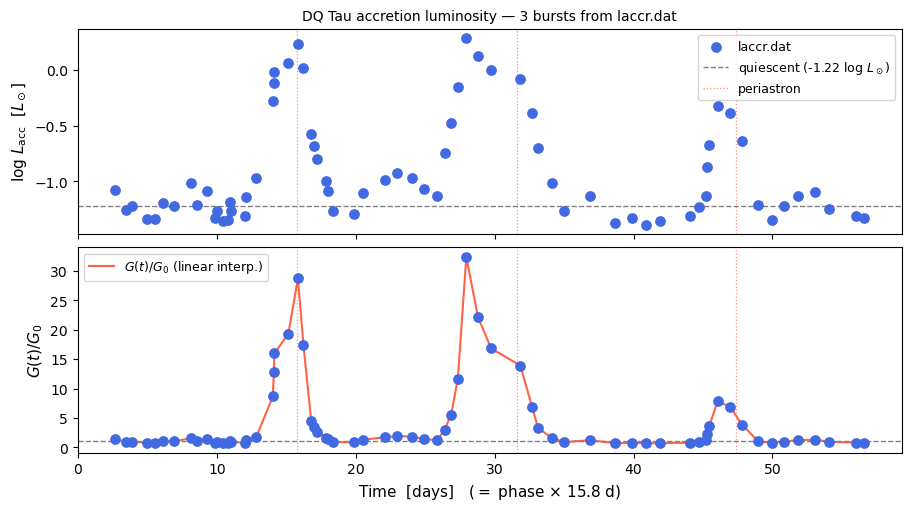

In [5]:
from scipy.interpolate import interp1d

# ── Reference data (Tofflemire+ 2025 X-Shooter, Table 1; kept for reference) ──
# Columns: BJD [d], log Lacc [Lsun]
_lacc_data = np.array([
    [2460559.86, -1.61],
    [2460560.88, -1.21],
    [2460562.84, -0.26],
    [2460563.82,  0.03],
    [2460564.84,  0.14],
    [2460571.85, -0.93],
    [2460572.81, -0.99],
    [2460573.78, -1.05],
    [2460583.85, -1.27],
    [2460585.84, -1.15],
    [2460586.81, -1.28],
    [2460587.79, -1.54],
    [2460595.75, -0.37],
    [2460598.75, -1.29],
    [2460599.74, -1.25],
    [2460600.72, -1.13],
    [2460605.73, -1.33],
    [2460634.84, -1.31],
    [2460635.63, -1.23],
    [2460647.60, -1.23],
    [2460649.67, -0.73],
    [2460651.59, -0.71],
    [2460671.58, -1.37],
    [2460673.59, -0.73],
    [2460678.60, -1.14],
])

# ── Primary data: laccr.dat ────────────────────────────────────────────────
# Column 1: orbital phase (phase 1 = first burst / periastron)
# Column 2: accretion luminosity [Lsun, linear]
_laccr      = np.loadtxt('laccr.dat', delimiter=',', comments='#')
_srt        = np.argsort(_laccr[:, 0])
phase_laccr = _laccr[_srt, 0]
Lacc_laccr  = _laccr[_srt, 1]

# Orbital period and time axis
P_orb   = 15.8                      # days — DQ Tau orbital period
t_laccr = phase_laccr * P_orb       # time in days (phase × period)

# Quiescent level: median of low-accretion points
Lacc_q = np.median(Lacc_laccr[Lacc_laccr < 0.15])
print(f"Quiescent Lacc  = {Lacc_q:.4f} Lsun")
print(f"Peak Lacc       = {Lacc_laccr.max():.3f} Lsun  (×{Lacc_laccr.max()/Lacc_q:.1f} over quiescent)")

# G-field enhancement relative to quiescent (G ∝ Lacc assumed)
G_enhance_laccr = Lacc_laccr / Lacc_q

# Time-based interpolator for the 3-burst light curve (used in run+plot cell below)
G_time_interp = interp1d(t_laccr, G_enhance_laccr, kind='linear',
                          bounds_error=False, fill_value=1.0)

# Phase-folded interpolator (used by the interactive widget's "Observed DQ Tau" mode)
_ph_fold = phase_laccr % 1.0
_ph_sort = np.argsort(_ph_fold)
_ph_s    = _ph_fold[_ph_sort]
_en_s    = G_enhance_laccr[_ph_sort]
_ph_wrap = np.concatenate([_ph_s - 1, _ph_s, _ph_s + 1])
_en_wrap = np.concatenate([_en_s,     _en_s, _en_s])
G_phase_interp = interp1d(_ph_wrap, _en_wrap, kind='linear',
                            bounds_error=False, fill_value=1.0)

# --- Diagnostic plot ---
t_fine = np.linspace(t_laccr.min(), t_laccr.max(), 800)
fig, axes = plt.subplots(2, 1, figsize=(9, 5), constrained_layout=True, sharex=True)

axes[0].scatter(t_laccr, np.log10(Lacc_laccr), c='royalblue', s=45, zorder=3,
                label='laccr.dat')
axes[0].axhline(np.log10(Lacc_q), color='gray', ls='--', lw=1,
                label=f'quiescent ({np.log10(Lacc_q):.2f} log $L_\\odot$)')
for p in [1, 2, 3]:
    axes[0].axvline(p * P_orb, color='tomato', ls=':', lw=0.9, alpha=0.7,
                    label='periastron' if p == 1 else None)
axes[0].set_ylabel(r'log $L_{\rm acc}$  [$L_\odot$]', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_title('DQ Tau accretion luminosity — 3 bursts from laccr.dat', fontsize=10)

axes[1].plot(t_fine, G_time_interp(t_fine), color='tomato', lw=1.5,
             label='$G(t)/G_0$ (linear interp.)')
axes[1].scatter(t_laccr, G_enhance_laccr, c='royalblue', s=45, zorder=3)
axes[1].axhline(1.0, color='gray', ls='--', lw=1)
for p in [1, 2, 3]:
    axes[1].axvline(p * P_orb, color='tomato', ls=':', lw=0.9, alpha=0.7)
axes[1].set_ylabel(r'$G(t)/G_0$', fontsize=11)
axes[1].set_xlabel(r'Time  [days]   ($= $ phase $\times$ 15.8 d)', fontsize=11)
axes[1].legend(fontsize=9)

plt.show()


In [6]:
def solve_water_ode_observed(nH, T, G0, tmax_days, G_phase_func,
                              period_days=15.8, x0=None, dt_days=0.05,
                              amp_scatter_dex=0.0, rng_seed=42, eps_O=2.4e-4):
    """
    Water ODE driven by an observed phase-folded G(phase) template.
    y = n(H2O)/n_H; starts from quiescent equilibrium by default.

    Parameters
    ----------
    G_phase_func    : callable, phase in [0,1] → G enhancement factor (G/G0)
    amp_scatter_dex : std dev [dex] applied per orbit to burst amplitude,
                      mimicking orbit-to-orbit variability (0 = no scatter)
    x0              : initial water abundance n(H2O)/n_H; None → quiescent equilibrium
    eps_O           : elemental oxygen abundance n_O/n_H (default: disk-depleted, 2.4e-4)
    """
    rng    = np.random.default_rng(rng_seed)
    dt     = dt_days * 86400.0
    nsteps = int(tmax_days / dt_days)

    # Initial condition: quiescent equilibrium if not specified
    kf_init  = k_formation(T, nH)
    kpd_init = k_photodiss(G0)
    if x0 is None:
        x0 = kf_init * eps_O / (kf_init + kpd_init)

    # Pre-draw per-orbit log-amplitude offsets
    n_orbits    = int(tmax_days / period_days) + 2
    log_offsets = rng.normal(0, amp_scatter_dex, size=n_orbits)

    t_arr = np.zeros(nsteps + 1)
    x_arr = np.zeros(nsteps + 1)
    G_arr = np.zeros(nsteps + 1)
    x = float(x0)

    for i in range(nsteps + 1):
        t_d    = i * dt_days
        phase  = (t_d % period_days) / period_days
        orbit  = int(t_d / period_days)

        enhance = float(G_phase_func(phase))
        # Apply scatter only to the excess above quiescent
        if amp_scatter_dex > 0.0 and enhance > 1.0:
            enhance = 1.0 + (enhance - 1.0) * 10 ** log_offsets[orbit]
        enhance = max(enhance, 1.0)

        G    = G0 * enhance
        kpd  = k_photodiss(G)
        kf   = k_formation(T, nH)
        dxdt = kf * (eps_O - x) - kpd * x
        t_arr[i] = t_d
        x_arr[i] = x
        G_arr[i] = G
        x = float(np.clip(x + dxdt * dt, 0.0, eps_O))

    return t_arr, x_arr, G_arr


## 9. Interactive explorer


In [7]:
# Disk-depleted oxygen abundance: solar value is 4.9e-4 (Asplund et al. 2009),
# but ~1.4e-4 is locked in refractory silicates (solar Si ~3.7e-5, ~3-4 O per Si)
# and a further fraction is in CO; consistent with ProDiMo disk chemistry models.
eps_O = 2.4e-4  # n_O / n_H  (available for water chemistry in warm disk layer)

# --- Widget definitions ---

style  = {'description_width': '160px'}
layout = widgets.Layout(width='360px')

w_logn   = widgets.FloatSlider(value=11.0, min=7.0,  max=13.0, step=0.5,
                                description='log₁₀ n_H  [cm⁻³]',
                                style=style, layout=layout, readout_format='.1f')
w_T      = widgets.IntSlider(value=300, min=100, max=800, step=50,
                              description='T  [K]',
                              style=style, layout=layout)
w_logG0  = widgets.FloatSlider(value=2.0, min=0.0, max=6.0, step=0.5,
                                description='log₁₀ G₀  [Draine]',
                                style=style, layout=layout, readout_format='.1f')
w_Gburst = widgets.IntSlider(value=10, min=2, max=100, step=1,
                              description='Burst factor',
                              style=style, layout=layout)
w_period = widgets.FloatSlider(value=15.8, min=5.0, max=60.0, step=0.5,
                                description='Period  [days]',
                                style=style, layout=layout, readout_format='.1f')
w_duty   = widgets.IntSlider(value=20, min=5, max=50, step=5,
                              description='Duty cycle  [%]',
                              style=style, layout=layout)
w_tmax   = widgets.IntSlider(value=120, min=30, max=365, step=10,
                              description='Integration  [days]',
                              style=style, layout=layout)
w_scatter = widgets.FloatSlider(value=0.0, min=0.0, max=1.0, step=0.1,
                                 description='Orbit scatter [dex]',
                                 style=style, layout=layout, readout_format='.1f')
w_mode   = widgets.Dropdown(options=[
                ('Sinusoidal (periodic)',               'sine'),
                ('Step function (single burst)',        'step'),
                ('Periodic square bursts',              'periodic_burst'),
                ('Observed DQ Tau — 3 bursts (laccr.dat)', 'laccr_3burst'),
                ('Observed DQ Tau — phase-folded',     'observed_dqtau')],
                value='sine',
                description='UV mode',
                style=style, layout=layout)

out = widgets.Output()

def n_eq(nH, T, G):
    """Equilibrium water abundance n(H2O)/n_H at constant UV field G."""
    kf  = k_formation(T, nH)
    kpd = k_photodiss(G)
    return kf * eps_O / (kf + kpd)

def fmt_days(s):
    d = s / 86400.0
    if d < 1:   return f"{d*24:.1f} hr"
    if d < 100: return f"{d:.1f} d"
    return f"{d/365:.2f} yr"

def run_laccr_3burst(nH, T, G0):
    """Run ODE over the full laccr.dat 3-burst time span."""
    dt      = 0.05  # days
    tmax    = t_laccr.max()
    nsteps  = int(tmax / dt)
    kf0     = k_formation(T, nH)
    kpd0    = k_photodiss(G0)
    x0      = kf0 * eps_O / (kf0 + kpd0)
    t_arr   = np.zeros(nsteps + 1)
    x_arr   = np.zeros(nsteps + 1)
    G_arr   = np.zeros(nsteps + 1)
    xv      = x0
    for ii in range(nsteps + 1):
        t_d   = ii * dt
        Gv    = G0 * float(G_time_interp(t_d))
        kpd   = k_photodiss(Gv)
        kf    = k_formation(T, nH)
        dxdt  = kf * (eps_O - xv) - kpd * xv
        t_arr[ii] = t_d
        x_arr[ii] = xv
        G_arr[ii] = Gv
        xv    = float(np.clip(xv + dxdt * dt * 86400.0, 0.0, eps_O))
    return t_arr, x_arr, G_arr

def update(*args):
    nH      = 10**w_logn.value
    T       = w_T.value
    G0      = 10**w_logG0.value
    G_burst = w_Gburst.value
    period  = w_period.value
    duty    = w_duty.value / 100.0
    tmax    = w_tmax.value
    mode    = w_mode.value
    scatter = w_scatter.value

    laccr_mode = (mode == 'laccr_3burst')

    if laccr_mode:
        t, x, G = run_laccr_3burst(nH, T, G0)
        G_peak  = G.max()
        t_plot  = t
        x_plot  = x
        G_plot  = G
        xlabel  = 'Time  [days]'
    elif mode == 'observed_dqtau':
        t, x, G = solve_water_ode_observed(
            nH, T, G0, tmax_days=tmax,
            G_phase_func=G_phase_interp,
            period_days=P_orb,
            amp_scatter_dex=scatter,
            eps_O=eps_O,
            dt_days=0.05)
        G_peak = G.max()
        i0 = first_peak_idx(G, G0)
        t_plot = t[i0:] - t[i0]
        x_plot = x[i0:]
        G_plot = G[i0:]
        xlabel = 'Time since first burst peak  [days]'
    else:
        t, x, G = solve_water_ode(nH, T, G0, G_burst, period, tmax,
                                   uv_mode=mode, duty_cycle=duty,
                                   eps_O=eps_O, dt_days=0.05)
        G_peak = G0 * G_burst
        i0 = first_peak_idx(G, G0)
        t_plot = t[i0:] - t[i0]
        x_plot = x[i0:]
        G_plot = G[i0:]
        xlabel = 'Time since first burst peak  [days]'

    neq_q = n_eq(nH, T, G0)
    neq_b = n_eq(nH, T, G_peak)

    t_dest  = fmt_days(1.0 / k_photodiss(G0))
    t_burst = fmt_days(1.0 / k_photodiss(G_peak))
    t_ref   = fmt_days(1.0 / k_formation(T, nH))
    info = (
        f"n_H = {nH:.2e} cm⁻³    T = {T} K    G₀ = {G0:.1e} Draine    burst ×{G_burst}    ε_O = {eps_O:.2e}\n"
        f"t_destroy (quiescent) = {t_dest:>10s}    "
        f"t_destroy (burst) = {t_burst:>10s}    "
        f"t_reform = {t_ref:>10s}\n"
        f"n_eq (quiescent) = {neq_q:.3e}    "
        f"n_eq (burst) = {neq_b:.3e}    "
        f"amplitude = {x_plot.max()-x_plot.min():.3e}"
    )

    with out:
        clear_output(wait=True)
        fig, axes = plt.subplots(3, 1, figsize=(9, 7),
                                  gridspec_kw={'height_ratios': [3, 2, 1.2]},
                                  constrained_layout=True)
        fig.suptitle('Water chemistry ODE — UV variability in a protoplanetary disk', fontsize=11)

        axes[0].plot(t_plot, x_plot, color='steelblue', lw=1.6, label='n(H₂O)/n_H')
        axes[0].axhline(neq_q, color='gray',   lw=1.1, ls='--', label='n_eq (quiescent G)')
        axes[0].axhline(neq_b, color='tomato', lw=1.1, ls=':',  label='n_eq (burst G)')
        if laccr_mode:
            for p in [1, 2, 3]:
                axes[0].axvline(p * P_orb, color='tomato', ls=':', lw=0.9, alpha=0.5,
                                label='periastron' if p == 1 else None)
        axes[0].set_yscale('log')
        axes[0].set_xlim(t_plot[0], t_plot[-1])
        axes[0].set_ylabel('n(H₂O)/n_H', fontsize=10)
        axes[0].legend(fontsize=8.5, framealpha=0.5)

        axes[1].plot(t_plot, G_plot, color='tomato', lw=1.4)
        axes[1].fill_between(t_plot, G_plot, alpha=0.15, color='tomato')
        if laccr_mode:
            axes[1].scatter(t_laccr, G0 * G_enhance_laccr, c='royalblue', s=25, zorder=3)
            for p in [1, 2, 3]:
                axes[1].axvline(p * P_orb, color='tomato', ls=':', lw=0.9, alpha=0.5)
        axes[1].set_xlim(t_plot[0], t_plot[-1])
        axes[1].set_ylabel('G(t)  [Draine]', fontsize=10)
        axes[1].set_xlabel(xlabel, fontsize=10)

        axes[2].axis('off')
        axes[2].text(0.02, 0.95, info, transform=axes[2].transAxes,
                     va='top', ha='left', fontsize=9.5, fontfamily='monospace')

        plt.show()

# Connect observers
for w in [w_logn, w_T, w_logG0, w_Gburst, w_period, w_duty, w_tmax, w_scatter, w_mode]:
    w.observe(update, names='value')

# Initial draw
update()

# --- Layout and display ---
col1 = widgets.VBox([w_mode, w_logn, w_T, w_logG0, w_Gburst])
col2 = widgets.VBox([w_period, w_duty, w_tmax, w_scatter])
controls = widgets.HBox([col1, col2])

display(widgets.VBox([controls, out]))


## 4. Quick timescale check — DQ Tau parameters

In [8]:
print_timescales(nH=1e11, T=300, G0=1e2, G_burst=10)

Destruction timescale (quiescent G=1e+02):  115.7 days
Destruction timescale (burst    G=1e+03):  11.6 days
Reformation timescale:                        0.1 days
Ratio  t_reform / t_dest_quiet:               0.00
Regime: quasi-static


## 6. Static run and publication-quality plot

=== Timescales ===
Destruction timescale (quiescent G=1e+02):  115.7 days
Destruction timescale (burst    G=1e+03):  11.6 days
Reformation timescale:                        0.1 days
Ratio  t_reform / t_dest_quiet:               0.00
Regime: quasi-static


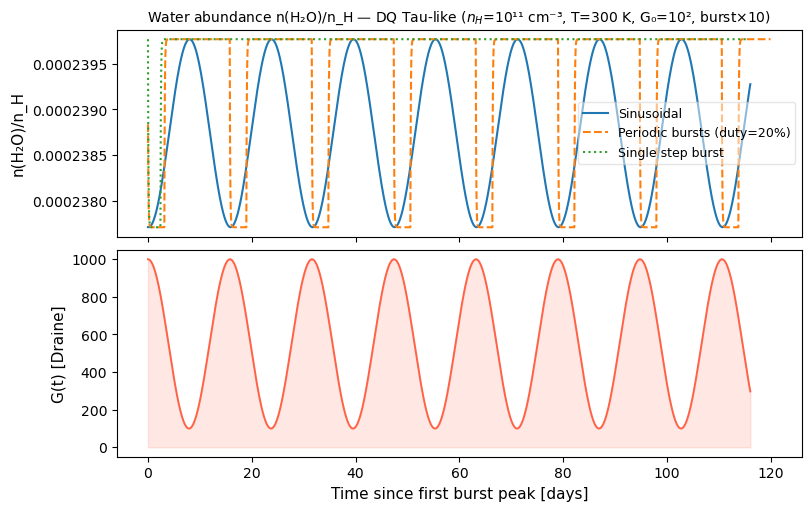

In [9]:
# DQ Tau-like parameters
params = dict(
    nH          = 1e11,   # cm^-3, warm molecular layer
    T           = 300,    # K
    G0          = 1e2,    # Draine units, quiescent
    G_burst     = 10,     # burst enhancement
    period_days = 15.8,   # days — DQ Tau orbital period
    tmax_days   = 120,    # days
)

print("=== Timescales ===")
print_timescales(params['nH'], params['T'], params['G0'], params['G_burst'])

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True, constrained_layout=True)
for mode, ls, label in [
    ('sine',            '-',  'Sinusoidal'),
    ('periodic_burst',  '--', 'Periodic bursts (duty=20%)'),
    ('step',            ':',  'Single step burst'),
]:
    t, x, G = solve_water_ode(**params, uv_mode=mode, dt_days=0.05)
    i0 = first_peak_idx(G, params['G0'])
    sl = slice(i0, None)
    axes[0].plot(t[sl] - t[i0], x[sl], ls=ls, lw=1.5, label=label)
    if mode == 'sine':
        axes[1].plot(t[sl] - t[i0], G[sl], color='tomato', lw=1.4)
        axes[1].fill_between(t[sl] - t[i0], G[sl], alpha=0.15, color='tomato')

axes[0].set_ylabel('n(H₂O)/n_H',     fontsize=11)
axes[1].set_ylabel('G(t) [Draine]',  fontsize=11)
axes[1].set_xlabel('Time since first burst peak [days]', fontsize=11)
axes[0].legend(fontsize=9, framealpha=0.5)
axes[0].set_title(f'Water abundance n(H₂O)/n_H — DQ Tau-like ($n_H$=10¹¹ cm⁻³, T=300 K, G₀=10², burst×10)', fontsize=10)

plt.show()


## 7. Parameter grid — response amplitude vs density and temperature

Useful for identifying where in parameter space the chemistry is time-dependent vs quasi-static.

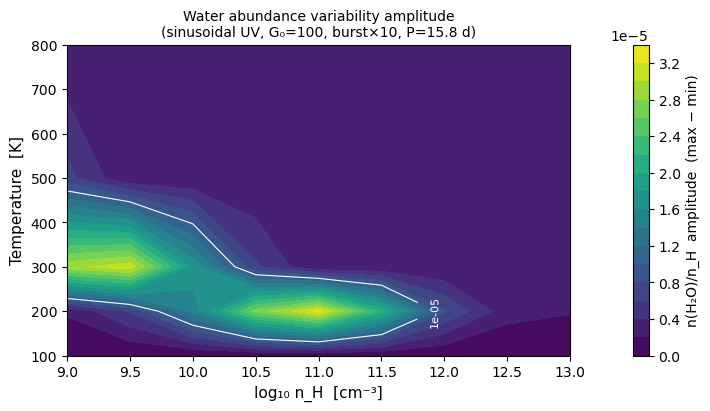

In [10]:
logn_grid = np.arange(9, 13.5, 0.5)
T_grid    = np.array([100, 200, 300, 500, 800])
amplitude = np.zeros((len(T_grid), len(logn_grid)))

for i, T in enumerate(T_grid):
    for j, logn in enumerate(logn_grid):
        _, x, _ = solve_water_ode(10**logn, T, G0=1e2, G_burst=10,
                                   period_days=15.8, tmax_days=120,
                                   uv_mode='sine', dt_days=0.1)
        # Use last 30% of run to avoid transient
        mask = np.arange(len(x)) > len(x) * 0.7
        amplitude[i, j] = x[mask].max() - x[mask].min()

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
im = ax.contourf(logn_grid, T_grid, amplitude, levels=20, cmap='viridis')
cs = ax.contour(logn_grid, T_grid, amplitude, levels=[1e-5, 5e-5, 1e-4, 2e-4, 3e-4],
                colors='white', linewidths=0.8)
ax.clabel(cs, fmt='%.0e', fontsize=8)
plt.colorbar(im, ax=ax, label='n(H₂O)/n_H  amplitude  (max − min)')
ax.set_xlabel('log₁₀ n_H  [cm⁻³]', fontsize=11)
ax.set_ylabel('Temperature  [K]',   fontsize=11)
ax.set_title('Water abundance variability amplitude\n(sinusoidal UV, G₀=100, burst×10, P=15.8 d)', fontsize=10)
plt.show()


In [11]:
# --- Run ---
nH, T, G0 = 1e11, 300.0, 1e2

t_pf, x_pf, G_pf = solve_water_ode_observed(
    nH, T, G0, tmax_days=120, G_phase_func=G_phase_interp)

t_sc, x_sc, G_sc = solve_water_ode_observed(
    nH, T, G0, tmax_days=120, G_phase_func=G_phase_interp,
    amp_scatter_dex=0.4, rng_seed=7)

# Idealized sine for reference (same peak enhancement)
G_burst_equiv = 10 ** (logLacc_obs.max() - logLacc_q)
t_si, x_si, G_si = solve_water_ode(nH, T, G0, G_burst=G_burst_equiv,
                                    period_days=15.8, tmax_days=120,
                                    uv_mode='sine', dt_days=0.05)

# --- Plot: start from first burst peak to avoid initial transient ---
i0_pf = first_peak_idx(G_pf, G0)
i0_si = first_peak_idx(G_si, G0)
sl_pf = slice(i0_pf, None)
sl_si = slice(i0_si, None)
t0_pf = t_pf[i0_pf]
t0_si = t_si[i0_si]

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True,
                          gridspec_kw={'height_ratios': [3, 2, 2]},
                          constrained_layout=True)
fig.suptitle(r'Water chemistry — DQ Tau observed $L_{\rm acc}$ as UV driver'
             r'  ($n_H$=10¹¹ cm⁻³, T=300 K, $G_0$=10²)', fontsize=10)

axes[0].plot(t_pf[sl_pf] - t0_pf, x_pf[sl_pf], color='steelblue',  lw=1.5, label='Phase-folded template')
axes[0].plot(t_sc[sl_pf] - t0_pf, x_sc[sl_pf], color='darkorange', lw=1.2, alpha=0.85,
             label='+ orbit-to-orbit scatter (σ = 0.4 dex)')
axes[0].plot(t_si[sl_si] - t0_si, x_si[sl_si], color='gray',       lw=1.1, ls='--', alpha=0.7,
             label=f'Sinusoidal reference (×{G_burst_equiv:.0f})')
axes[0].set_ylabel('n(H₂O)/n_H', fontsize=11)
axes[0].legend(fontsize=9, framealpha=0.5)

axes[1].plot(t_pf[sl_pf] - t0_pf, G_pf[sl_pf], color='steelblue',  lw=1.3, label='Phase-folded')
axes[1].plot(t_sc[sl_pf] - t0_pf, G_sc[sl_pf], color='darkorange', lw=1.1, alpha=0.8, label='With scatter')
axes[1].fill_between(t_pf[sl_pf] - t0_pf, G_pf[sl_pf], alpha=0.12, color='steelblue')
axes[1].set_ylabel('G(t)  [Draine]', fontsize=11)
axes[1].legend(fontsize=9, framealpha=0.5)

axes[2].plot(t_pf[sl_pf] - t0_pf, np.log10(G_pf[sl_pf]), color='steelblue',  lw=1.3)
axes[2].plot(t_sc[sl_pf] - t0_pf, np.log10(G_sc[sl_pf]), color='darkorange', lw=1.1, alpha=0.8)
axes[2].set_ylabel('log G(t)', fontsize=11)
axes[2].set_xlabel('Time since first burst peak [days]', fontsize=11)

plt.show()


NameError: name 'logLacc_obs' is not defined